# Sesion 9b — Introduccion a Graficas con Matplotlib
## Diplomado: Machine Learning en Seguros · FC UNAM
### Miercoles 6 de mayo de 2026  ·  Parte 2 de la sesion

---

> **Este notebook usa la tabla maestra construida en la primera parte de la sesion.**
> Guarda el DataFrame al final — se lo compartiras al otro profesor para el viernes.

---

## Lo que aprenderemos

No vamos a saltar directo a 'hacer una grafica'. Vamos a entender primero **por qué**
matplotlib funciona como funciona, para que puedas construir cualquier grafica
desde cero sin depender de ejemplos copiados.

El recorrido:
1. Filosofia de matplotlib — la jerarquia que lo explica todo
2. Configuracion global — definir el estilo una sola vez
3. La grafica minima — la mas simple posible
4. Agregar elementos uno por uno
5. Tipos de grafica — para que sirve cada una
6. Subplots — multiples graficas en una figura
7. Cuatro graficas sobre la cartera real

---
## 0. Cargar la Tabla Maestra

Cargamos el DataFrame que construimos en la primera parte de la sesion.

In [3]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Cargar la tabla maestra guardada al final de S9
df = pd.read_parquet('../sesion_10/datos/cartera_q1_2026_final.parquet')

print(f'Tabla maestra: {df.shape}')
print(f'Columnas: {list(df.columns)}')
df.head(3)

Tabla maestra: (50000, 52)
Columnas: ['id_poliza', 'num_poliza', 'nombre', 'apellido_paterno', 'apellido_materno', 'rfc', 'edad', 'sexo', 'estado_civil', 'ocupacion', 'ramo', 'plan', 'fecha_emision', 'fecha_inicio_vigencia', 'fecha_fin_vigencia', 'num_renovaciones', 'status_poliza', 'motivo_baja', 'canal_venta', 'marca_vehiculo', 'modelo_vehiculo', 'tipo_vehiculo', 'suma_asegurada', 'deducible', 'prima_neta', 'prima_total', 'forma_pago', 'agente_id', 'estado', 'municipio', 'codigo_postal', 'nombre_agente', 'region', 'tipo_agente', 'comision_pct', 'n_siniestros', 'monto_reclamado', 'monto_pagado', 'tiene_abierto', 'tipo_principal', 'prima_mensual', 'loss_ratio', 'comision_est', 'nivel_riesgo', 'anio_emision', 'mes_emision', 'trimestre', 'segmento_prima_fijo', 'cuartil_prima', 'cod_ramo', 'anio_poliza', 'ramo_desde_codigo']


,id_poliza,num_poliza,nombre,apellido_paterno,apellido_materno,rfc,edad,sexo,estado_civil,ocupacion,...,comision_est,nivel_riesgo,anio_emision,mes_emision,trimestre,segmento_prima_fijo,cuartil_prima,cod_ramo,anio_poliza,ramo_desde_codigo
0,POL-000001,Vid-21-000001,Gabriela,Moreno,Vega,MOGV020429CG6,24,F,Union libre,Independiente,...,5892.41952,BAJO,2021,11,4,Premium,Q4,VID,2021,Vida
1,POL-000002,Aut-19-000002,Valeria,Torres,Castillo,TOVC020815IA8,23,F,Casado,Contador,...,882.44100,BAJO,2019,8,3,Alta,Q1,AUT,2019,Autos
2,POL-000003,GMM-22-000003,Fernanda,Ramos,Silva,RAFS941018BC1,31,M,Union libre,Ingeniero,...,1995.45984,BAJO,2022,7,3,Premium,Q3,GMM,2022,GMM


---
## 1. La Filosofia de Matplotlib

Antes de escribir una sola linea de codigo, hay que entender como piensa matplotlib.
Esto evita el 90% de la confusion que tienen los principiantes.

### Todo tiene una jerarquia de 3 niveles

```
Figure  ← la hoja en blanco (el contenedor de todo)
  └── Axes  ← el area donde se dibuja (los ejes, la grafica)
        ├── Line2D     (lineas)
        ├── Rectangle  (barras)
        ├── PathCollection (puntos de scatter)
        ├── Text       (titulos, etiquetas)
        └── ...        (todo lo que ves en la grafica)
```

**Figure** = la hoja. Puede contener una o varias graficas.

**Axes** = el area de dibujo. Es donde realmente vive la grafica.
Cuando la gente dice 'la grafica', en realidad habla del Axes.

**Elementos** = todo lo que esta dentro del Axes: barras, puntos, lineas, titulos.

> La confusion tipica: matplotlib tiene DOS interfaces.
> La **rapida** (`plt.plot(...)`) y la **orientada a objetos** (`fig, ax = plt.subplots()`).
> Vamos a aprender la orientada a objetos — es la correcta para trabajo real.

<class 'matplotlib.figure.Figure'>
<class 'matplotlib.axes._axes.Axes'>
Axes dentro de Figure: [<Axes: >]


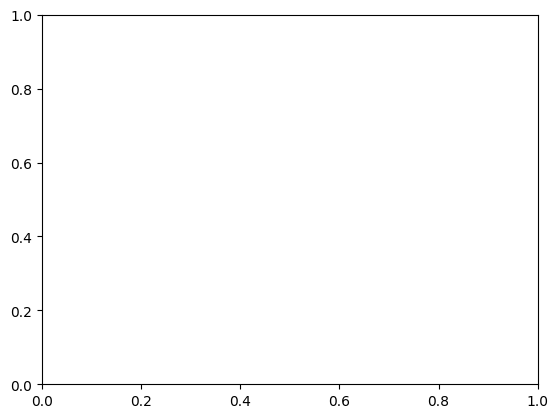

In [4]:
# ── Demostrar la jerarquia ───────────────────────────────────────────────────
fig, ax = plt.subplots()  # crea Figure Y Axes al mismo tiempo

print(type(fig))   # <class 'matplotlib.figure.Figure'>
print(type(ax))    # <class 'matplotlib.axes._axes.Axes'>

# La Figure contiene al Axes
print(f'Axes dentro de Figure: {fig.get_axes()}')

# El Axes esta vacio — no hemos dibujado nada todavia
plt.show()
# Veremos una caja vacia — eso es un Axes sin contenido

---
## 2. Configuracion Global — Definir el Estilo Una Sola Vez

En lugar de personalizar cada grafica individualmente,
definimos el estilo base una vez al inicio del notebook.
Todas las graficas que hagamos despues heredan esa configuracion.

Esto es lo que hacen los analistas en produccion — no repetir parametros.

In [5]:
# ── Configuracion global con rcParams ────────────────────────────────────────
# rcParams es el diccionario de configuracion global de matplotlib
# 'rc' viene de 'runtime configuration'

matplotlib.rcParams['figure.dpi']         = 120    # resolucion (pantalla vs print)
matplotlib.rcParams['figure.figsize']      = (10, 5) # tamano por defecto
matplotlib.rcParams['font.family']         = 'sans-serif'
matplotlib.rcParams['font.size']           = 11
matplotlib.rcParams['axes.titlesize']      = 14
matplotlib.rcParams['axes.titleweight']    = 'bold'
matplotlib.rcParams['axes.labelsize']      = 11
matplotlib.rcParams['axes.spines.top']     = False  # quitar borde superior
matplotlib.rcParams['axes.spines.right']   = False  # quitar borde derecho
matplotlib.rcParams['axes.grid']           = True
matplotlib.rcParams['grid.alpha']          = 0.3
matplotlib.rcParams['lines.linewidth']     = 2
matplotlib.rcParams['lines.markersize']    = 7

# Paleta de colores del diplomado
COLORES = {
    'GMM':                   '#0D7A8A',
    'Autos':                 '#1A5276',
    'Vida':                  '#1E8449',
    'Accidentes Personales': '#6C3483',
    'BAJO':                  '#1E8449',
    'MEDIO':                 '#F4A261',
    'ALTO':                  '#C0392B',
}

print('Configuracion global aplicada.')
print('Todas las graficas que hagamos de aqui en adelante usaran este estilo.')

Configuracion global aplicada.
Todas las graficas que hagamos de aqui en adelante usaran este estilo.


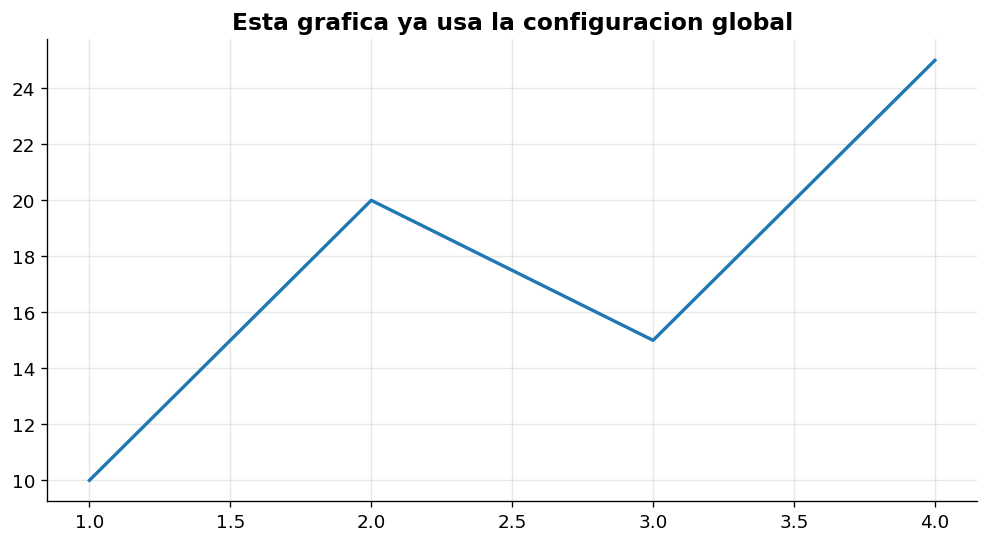

In [6]:
# ── Ver el efecto — grafica con y sin configuracion ──────────────────────────
# Ahora una grafica simple ya se ve diferente

fig, ax = plt.subplots()   # usa figsize=(10,5) y dpi=120 automaticamente
ax.plot([1, 2, 3, 4], [10, 20, 15, 25])
ax.set_title('Esta grafica ya usa la configuracion global')
plt.show()

# Compara mentalmente con la caja vacia de antes — misma cantidad de codigo,
# resultado mucho mejor.

---
## 3. La Grafica Minima

Empezamos con lo mas simple posible — una grafica de barras con 3 valores.
El objetivo es entender el patron basico antes de agregar complejidad.

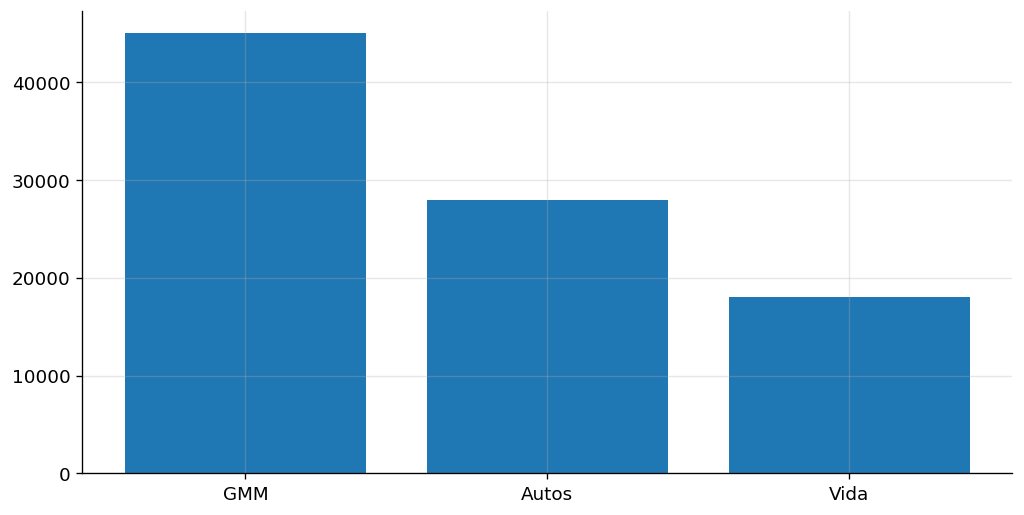

In [7]:
# ── La grafica minima — 3 lineas de codigo ───────────────────────────────────
fig, ax = plt.subplots()

ax.bar(['GMM', 'Autos', 'Vida'], [45000, 28000, 18000])

plt.show()

# Eso es todo lo que NECESITAS para una grafica.
# Ahora vamos a agregar elementos uno por uno para entender para que sirve cada uno.

---
## 4. Agregar Elementos Uno por Uno

Cada elemento que agregas tiene un proposito.
Vamos a ir de la grafica minima a una grafica completa,
agregando UNA cosa a la vez.

In [8]:
# ── Paso 1: datos reales en lugar de valores inventados ─────────────────────
# Calculamos la prima total por ramo desde la tabla maestra
prima_por_ramo = df.groupby('ramo')['prima_total'].sum().sort_values(ascending=True)
print(prima_por_ramo)

ramo
Accidentes Personales    2.498068e+07
Autos                    2.538235e+08
Vida                     4.543321e+08
GMM                      7.310223e+08
Name: prima_total, dtype: float64


C:\Users\gusta\AppData\Local\Temp\ipykernel_9348\516402602.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prima_por_ramo = df.groupby('ramo')['prima_total'].sum().sort_values(ascending=True)


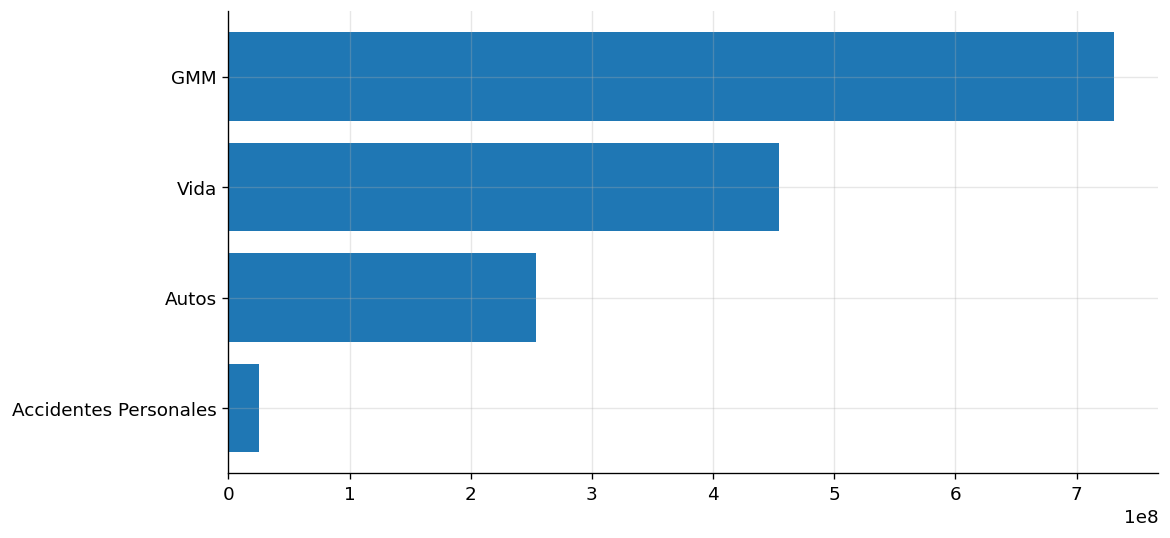

In [9]:
# ── Paso 2: la grafica minima con datos reales ───────────────────────────────
fig, ax = plt.subplots()
ax.barh(prima_por_ramo.index, prima_por_ramo.values)
plt.show()

# Problema 1: los numeros en el eje X son enormes y dificiles de leer
# Problema 2: no hay titulo — no sabemos que representa
# Problema 3: no hay etiquetas en los ejes
# Vamos a resolver cada uno

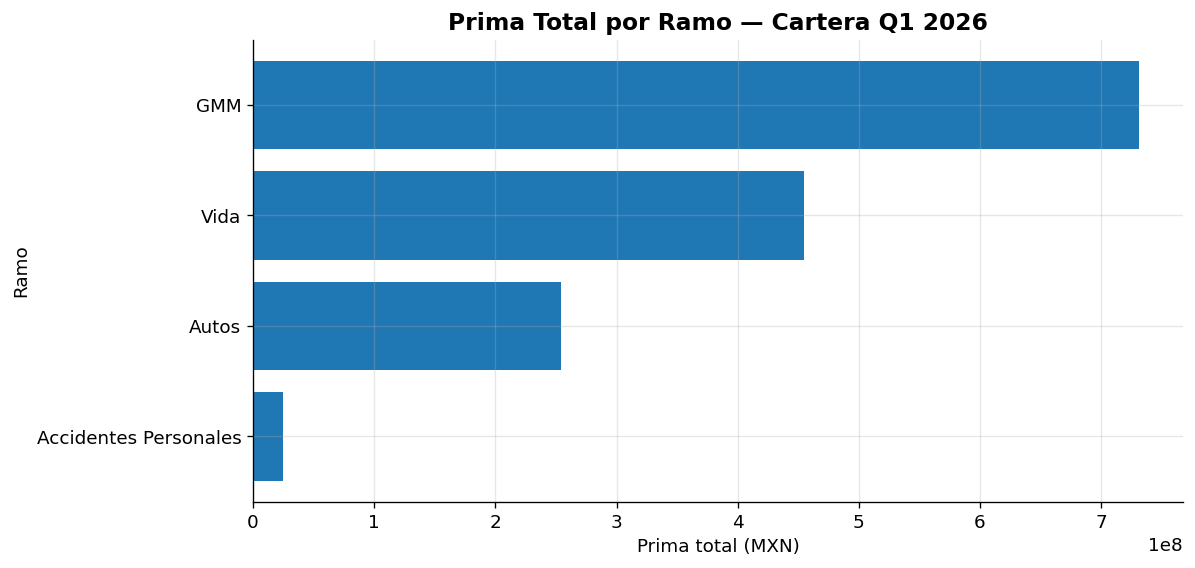

In [10]:
# ── Paso 3: agregar titulo y etiquetas de ejes ───────────────────────────────
fig, ax = plt.subplots()
ax.barh(prima_por_ramo.index, prima_por_ramo.values)

# Titulo — responde: ¿que muestra esta grafica?
ax.set_title('Prima Total por Ramo — Cartera Q1 2026')

# Etiquetas de ejes — responde: ¿que unidad tiene cada eje?
ax.set_xlabel('Prima total (MXN)')
ax.set_ylabel('Ramo')

plt.show()

# Mejor, pero los numeros del eje X siguen siendo ilegibles

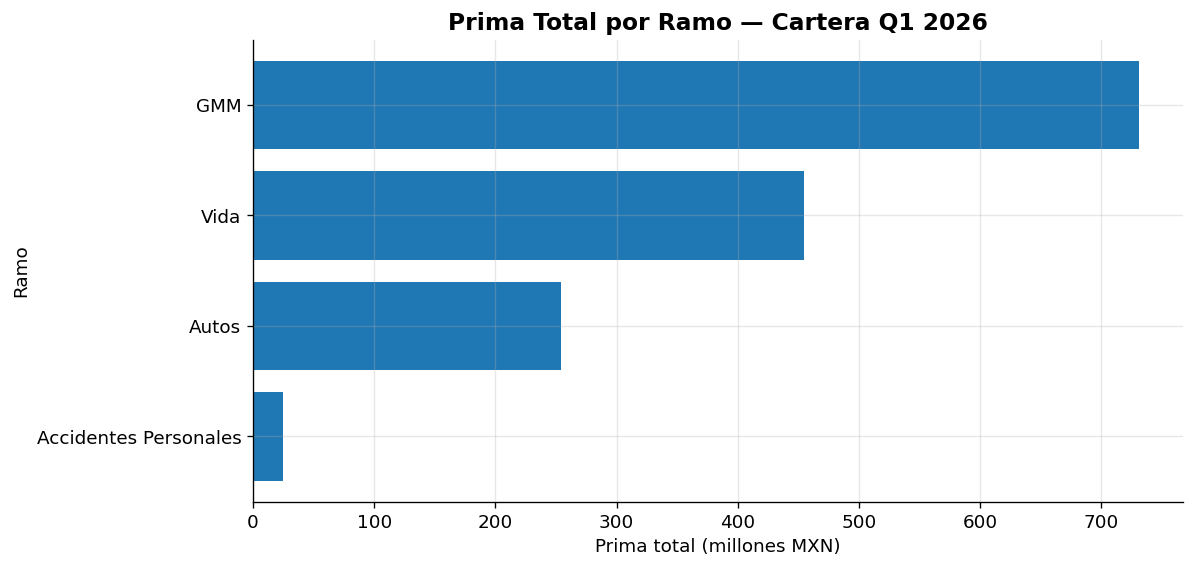

In [11]:
# ── Paso 4: formatear el eje numerico ────────────────────────────────────────
fig, ax = plt.subplots()
ax.barh(prima_por_ramo.index, prima_por_ramo.values / 1_000_000)  # en millones

ax.set_title('Prima Total por Ramo — Cartera Q1 2026')
ax.set_xlabel('Prima total (millones MXN)')
ax.set_ylabel('Ramo')

plt.show()

# Mucho mejor. Ahora agregamos color para reforzar la identidad visual.

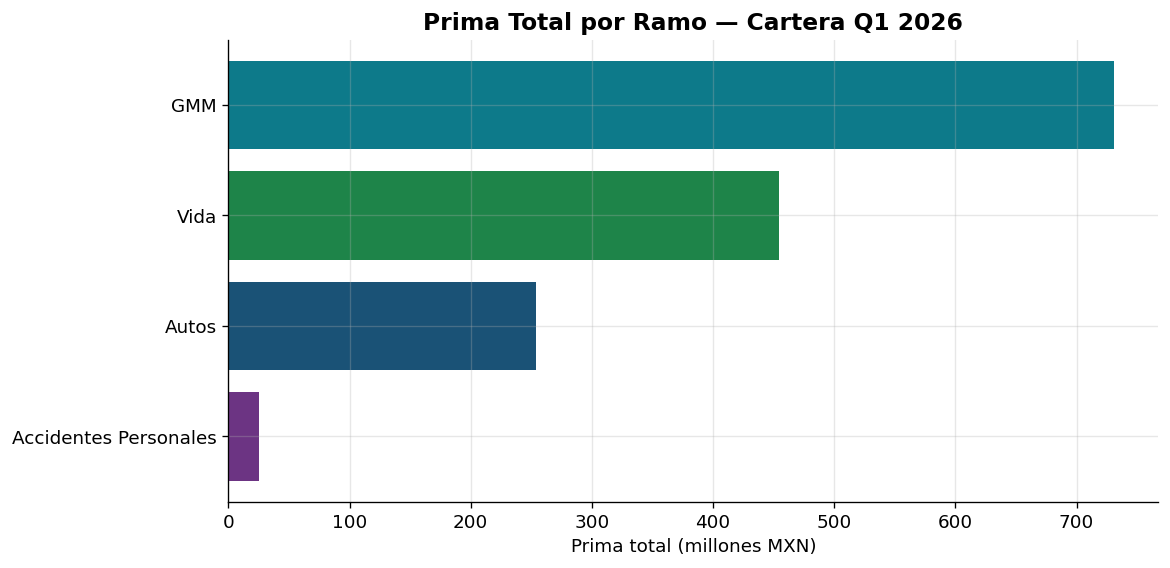

In [12]:
# ── Paso 5: agregar color con significado ────────────────────────────────────
fig, ax = plt.subplots()

# El color no es decoracion — refuerza la informacion
colores_barras = [COLORES.get(ramo, '#888888') for ramo in prima_por_ramo.index]

ax.barh(prima_por_ramo.index, prima_por_ramo.values / 1_000_000,
        color=colores_barras)

ax.set_title('Prima Total por Ramo — Cartera Q1 2026')
ax.set_xlabel('Prima total (millones MXN)')

plt.show()

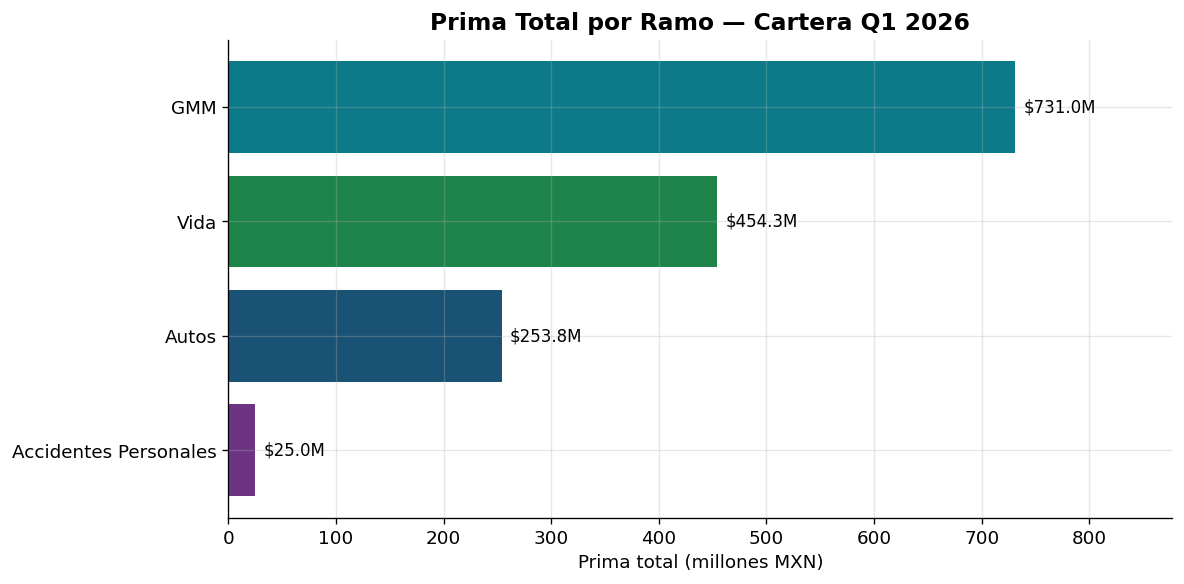

In [13]:
# ── Paso 6: agregar etiquetas de valor sobre las barras ──────────────────────
# El lector no deberia tener que estimar el valor mirando el eje
fig, ax = plt.subplots()

colores_barras = [COLORES.get(ramo, '#888888') for ramo in prima_por_ramo.index]
barras = ax.barh(prima_por_ramo.index, prima_por_ramo.values / 1_000_000,
                 color=colores_barras)

# bar_label: agrega el valor al final de cada barra automaticamente
ax.bar_label(barras, fmt='$%.1fM', padding=5, fontsize=10)

# Dar espacio a la derecha para que los labels no queden cortados
ax.set_xlim(0, prima_por_ramo.max() / 1_000_000 * 1.2)

ax.set_title('Prima Total por Ramo — Cartera Q1 2026')
ax.set_xlabel('Prima total (millones MXN)')

plt.tight_layout()
plt.show()

# Esta es la grafica completa — construida elemento por elemento.
# Cada linea tiene un proposito que entiendes.

### El patron que usaras siempre

```python
fig, ax = plt.subplots(figsize=(ancho, alto))

# 1. Dibujar los datos
ax.TIPO_DE_GRAFICA(x, y, opciones)

# 2. Titulo y etiquetas
ax.set_title('...')
ax.set_xlabel('...')
ax.set_ylabel('...')

# 3. Ajustes opcionales (limites, formato, leyenda)
ax.set_xlim(...)  # si necesitas controlar el rango
ax.legend()       # si hay varias series

# 4. Mostrar
plt.tight_layout()  # evita que los elementos se corten
plt.show()
```

---
## 5. Tipos de Grafica — Para Que Sirve Cada Una

La decision mas importante no es 'como hago esta grafica'
sino 'que tipo de grafica responde mejor mi pregunta'.

| Tipo | Pregunta que responde | Metodo |
|------|-----------------------|--------|
| Barras | ¿Cuanto tiene cada grupo? | `ax.bar()` / `ax.barh()` |
| Linea | ¿Como cambia algo en el tiempo? | `ax.plot()` |
| Histograma | ¿Como se distribuye una variable? | `ax.hist()` |
| Dispersion | ¿Hay relacion entre dos variables? | `ax.scatter()` |
| Boxplot | ¿Donde estan la mediana y los outliers? | `ax.boxplot()` |
| Pastel | ¿Que proporcion tiene cada parte? | `ax.pie()` (usar con cuidado) |

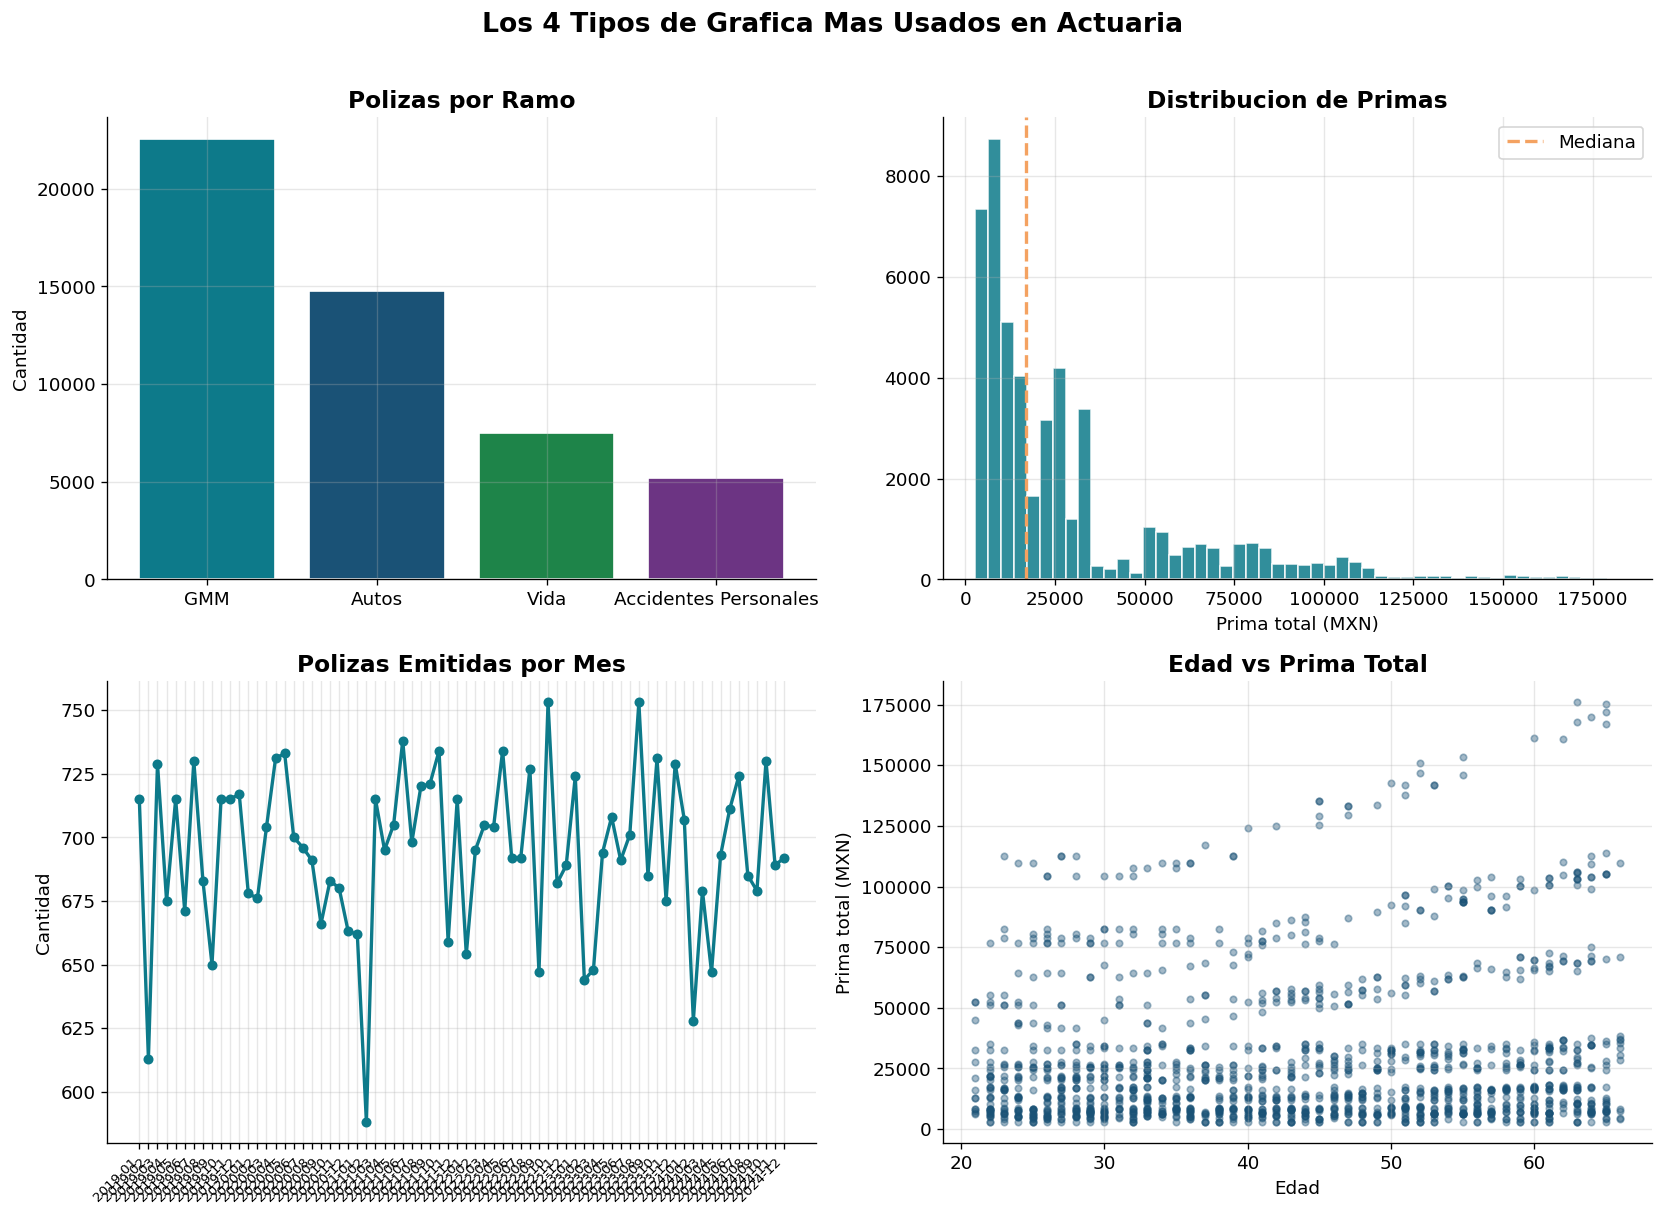

In [14]:
# ── Los 4 tipos mas usados en actuaria — mini ejemplos ───────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Barras: ¿cuantas polizas hay por ramo? ────────────────────────────────────
conteo = df['ramo'].value_counts()
axes[0,0].bar(conteo.index, conteo.values,
              color=[COLORES.get(r,'gray') for r in conteo.index],
              edgecolor='white')
axes[0,0].set_title('Polizas por Ramo')
axes[0,0].set_ylabel('Cantidad')

# ── Histograma: ¿como se distribuyen las primas? ──────────────────────────────
axes[0,1].hist(df['prima_total'].dropna(), bins=50,
               color='#0D7A8A', edgecolor='white', alpha=0.85)
axes[0,1].axvline(df['prima_total'].median(), color='#F4A261',
                  linewidth=2, linestyle='--', label='Mediana')
axes[0,1].set_title('Distribucion de Primas')
axes[0,1].set_xlabel('Prima total (MXN)')
axes[0,1].legend()

# ── Linea: ¿como evoluciona la emision en el tiempo? ─────────────────────────
por_mes = (df.groupby(df['fecha_emision'].dt.to_period('M'))
             .size()
             .reset_index(name='polizas'))
por_mes['fecha_str'] = por_mes['fecha_emision'].astype(str)
axes[1,0].plot(por_mes['fecha_str'], por_mes['polizas'],
               marker='o', color='#0D7A8A', markersize=5)
axes[1,0].set_title('Polizas Emitidas por Mes')
axes[1,0].set_ylabel('Cantidad')
plt.setp(axes[1,0].xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

# ── Dispersion: ¿relacion entre edad y prima? ─────────────────────────────────
muestra = df.sample(1500, random_state=42)
axes[1,1].scatter(muestra['edad'], muestra['prima_total'],
                  alpha=0.4, s=15, color='#1A5276')
axes[1,1].set_title('Edad vs Prima Total')
axes[1,1].set_xlabel('Edad')
axes[1,1].set_ylabel('Prima total (MXN)')

fig.suptitle('Los 4 Tipos de Grafica Mas Usados en Actuaria',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Subplots — Multiples Graficas en Una Figura

`plt.subplots(filas, columnas)` crea una cuadricula de Axes.
Cada posicion en la cuadricula es un Axes independiente.

```python
fig, axes = plt.subplots(1, 2)   # 1 fila, 2 columnas → axes[0], axes[1]
fig, axes = plt.subplots(2, 2)   # 2x2 → axes[0,0], axes[0,1], axes[1,0], axes[1,1]
fig, axes = plt.subplots(1, 3)   # 1 fila, 3 columnas → axes[0], axes[1], axes[2]
```

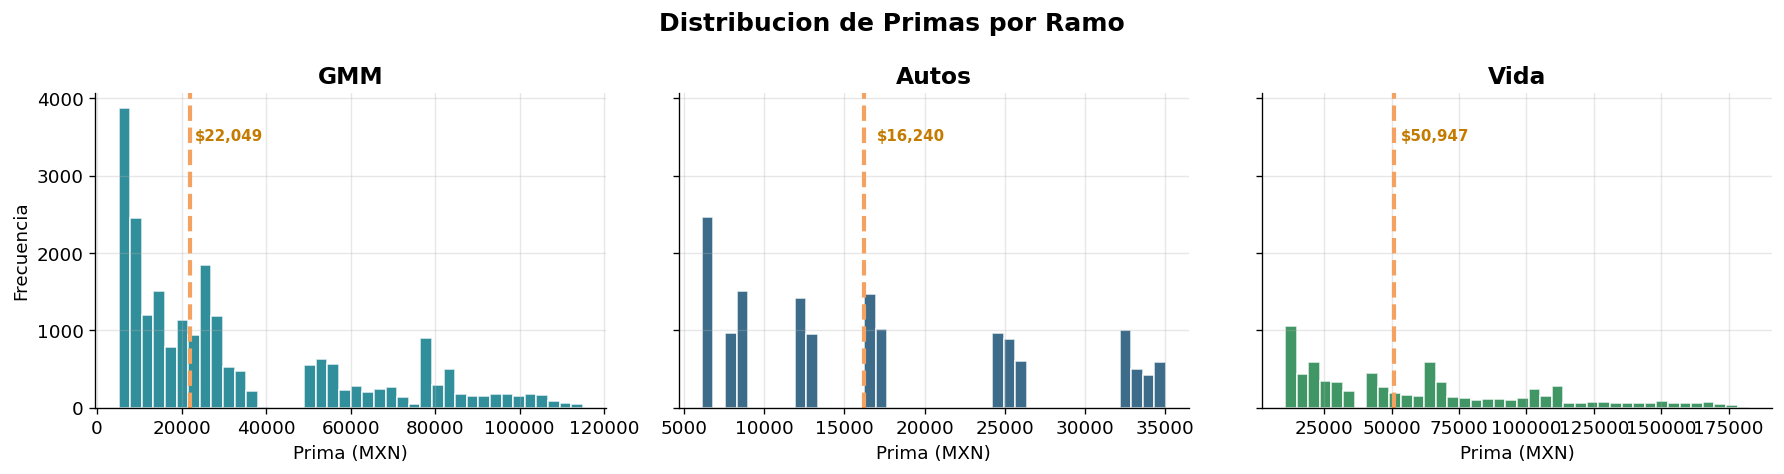

In [15]:
# ── Ejemplo: un histograma por ramo lado a lado ───────────────────────────────
ramos_principales = ['GMM', 'Autos', 'Vida']

# 1 fila, 3 columnas
# sharey=True: los 3 graficos comparten el eje Y (misma escala — permite comparar)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, ramo in zip(axes, ramos_principales):
    datos = df[df['ramo'] == ramo]['prima_total'].dropna()

    ax.hist(datos, bins=40,
            color=COLORES.get(ramo, 'gray'),
            edgecolor='white', alpha=0.85)

    # Linea de mediana
    mediana = datos.median()
    ax.axvline(mediana, color='#F4A261', linewidth=2.5,
               linestyle='--', label=f'Mediana')

    # Anotar el valor de la mediana
    ax.text(mediana * 1.05, ax.get_ylim()[1] * 0.85,
            f'${mediana:,.0f}', fontsize=9, color='#C47B00', fontweight='bold')

    ax.set_title(ramo)
    ax.set_xlabel('Prima (MXN)')
    if ax == axes[0]:         # solo el primero tiene etiqueta Y
        ax.set_ylabel('Frecuencia')

fig.suptitle('Distribucion de Primas por Ramo',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Observa: zip(axes, ramos_principales) itera los dos juntos.
# En la primera iteracion: ax=axes[0], ramo='GMM'
# En la segunda:           ax=axes[1], ramo='Autos'
# En la tercera:           ax=axes[2], ramo='Vida'

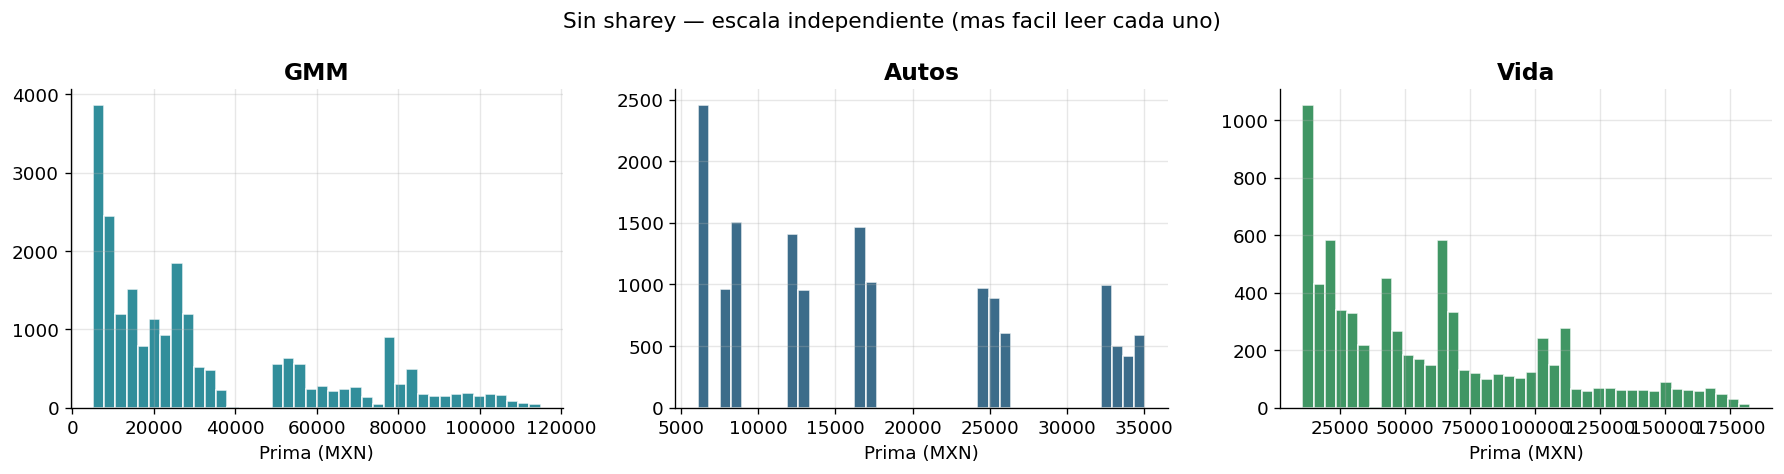

In [16]:
# ── sharey y sharex — cuando usarlos ─────────────────────────────────────────
# sharey=True:  todos los subplots comparten escala del eje Y
#               UTIL cuando quieres COMPARAR magnitudes entre grupos
#               (si GMM tiene primas de $3k y Vida de $11k, sharey muestra esa diferencia)

# sharey=False: cada subplot tiene su propia escala
#               UTIL cuando los grupos tienen ordenes de magnitud muy diferentes

# Ejemplo — misma grafica SIN sharey:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)  # escala independiente

for ax, ramo in zip(axes, ramos_principales):
    datos = df[df['ramo'] == ramo]['prima_total'].dropna()
    ax.hist(datos, bins=40, color=COLORES.get(ramo,'gray'), edgecolor='white', alpha=0.85)
    ax.set_title(ramo)
    ax.set_xlabel('Prima (MXN)')

fig.suptitle('Sin sharey — escala independiente (mas facil leer cada uno)',
             fontsize=13)
plt.tight_layout()
plt.show()

# La eleccion entre sharey=True/False es una decision de comunicacion,
# no tecnica. Depende de lo que quieres enfatizar.

---
## 7. Cuatro Graficas sobre la Cartera Real

Ahora si aplicamos todo lo aprendido a preguntas reales de negocio.
Cada grafica responde una pregunta especifica.

C:\Users\gusta\AppData\Local\Temp\ipykernel_9348\2817955013.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prima_por_ramo = df.groupby('ramo')['prima_total'].sum().sort_values()


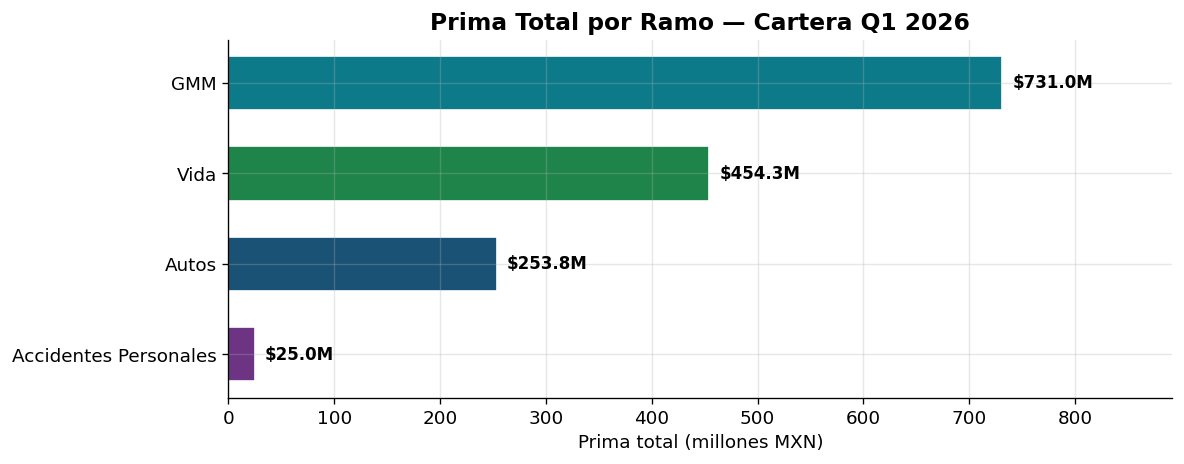

In [17]:
# ── Grafica 1: ¿Cuanto representa cada ramo en la cartera? ──────────────────
# Pregunta de negocio: ¿donde esta concentrada la prima?
# Tipo: barras horizontales (mejor que verticales cuando los nombres son largos)

prima_por_ramo = df.groupby('ramo')['prima_total'].sum().sort_values()

fig, ax = plt.subplots(figsize=(10, 4))

colores_barras = [COLORES.get(r, '#888888') for r in prima_por_ramo.index]
barras = ax.barh(prima_por_ramo.index, prima_por_ramo.values / 1_000_000,
                 color=colores_barras, height=0.6, edgecolor='white')

ax.bar_label(barras, fmt='$%.1fM', padding=6, fontsize=10, fontweight='bold')
ax.set_xlim(0, prima_por_ramo.max() / 1_000_000 * 1.22)
ax.set_xlabel('Prima total (millones MXN)')
ax.set_title('Prima Total por Ramo — Cartera Q1 2026')

plt.tight_layout()
plt.show()

C:\Users\gusta\AppData\Local\Temp\ipykernel_9348\1386346702.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([df['fecha_emision'].dt.to_period('M'), 'ramo'])
C:\Users\gusta\AppData\Local\Temp\ipykernel_9348\1386346702.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ramo, grupo in por_mes_ramo.groupby('ramo'):


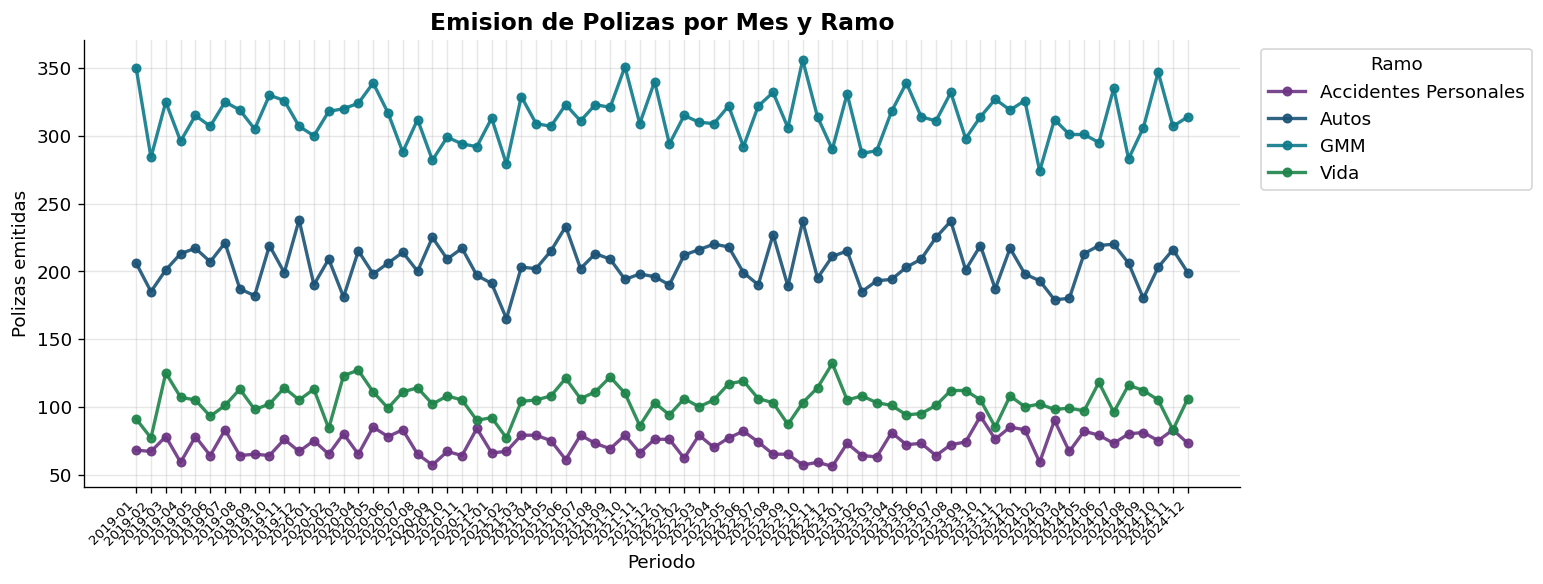

In [18]:
# ── Grafica 2: ¿Como evoluciono la emision mes a mes? ────────────────────────
# Pregunta de negocio: ¿hay estacionalidad? ¿tendencia?
# Tipo: linea (muestra continuidad en el tiempo)

por_mes_ramo = (
    df.groupby([df['fecha_emision'].dt.to_period('M'), 'ramo'])
    .size()
    .reset_index(name='polizas')
)
por_mes_ramo['periodo'] = por_mes_ramo['fecha_emision'].astype(str)

fig, ax = plt.subplots(figsize=(13, 5))

for ramo, grupo in por_mes_ramo.groupby('ramo'):
    ax.plot(grupo['periodo'], grupo['polizas'],
            marker='o', label=ramo,
            color=COLORES.get(ramo, '#888888'),
            markersize=5, alpha=0.9)

ax.set_title('Emision de Polizas por Mes y Ramo')
ax.set_xlabel('Periodo')
ax.set_ylabel('Polizas emitidas')
ax.legend(title='Ramo', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

C:\Users\gusta\AppData\Local\Temp\ipykernel_9348\1966754493.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_box,


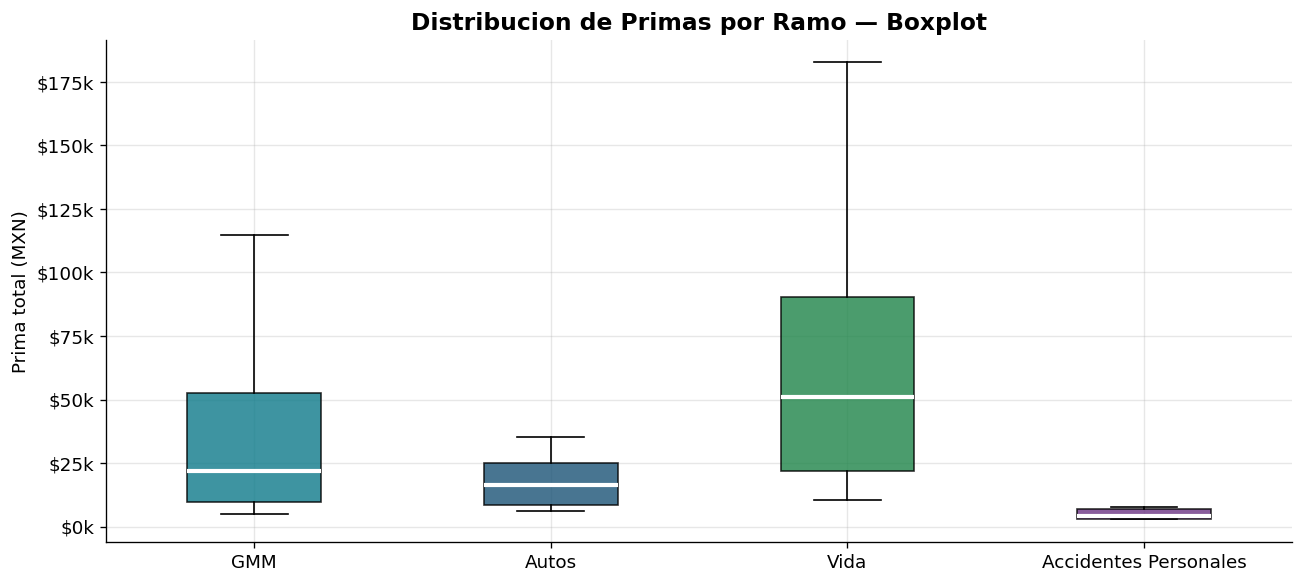

In [19]:
# ── Grafica 3: ¿Como se distribuyen las primas dentro de cada ramo? ─────────
# Pregunta de negocio: ¿donde estan los outliers? ¿es simetrica la distribucion?
# Tipo: boxplot (muestra mediana, IQR y outliers en una sola figura)

ramos_ord = ['GMM','Autos','Vida','Accidentes Personales']
datos_box = [df[df['ramo']==r]['prima_total'].dropna().values for r in ramos_ord]

fig, ax = plt.subplots(figsize=(11, 5))

bp = ax.boxplot(datos_box,
                labels=ramos_ord,
                patch_artist=True,      # rellena las cajas con color
                medianprops=dict(color='white', linewidth=2.5),
                flierprops=dict(marker='.', alpha=0.3, markersize=4))

# Colorear cada caja con el color del ramo
for patch, ramo in zip(bp['boxes'], ramos_ord):
    patch.set_facecolor(COLORES.get(ramo, 'gray'))
    patch.set_alpha(0.8)

ax.set_title('Distribucion de Primas por Ramo — Boxplot')
ax.set_ylabel('Prima total (MXN)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.show()

# Como leer un boxplot:
# - Linea central = mediana
# - Caja = 50% central de los datos (IQR = Q3 - Q1)
# - Bigotes = hasta 1.5 * IQR desde la caja
# - Puntos fuera = outliers

C:\Users\gusta\AppData\Local\Temp\ipykernel_9348\4134336203.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ramo, grupo in muestra.groupby('ramo'):


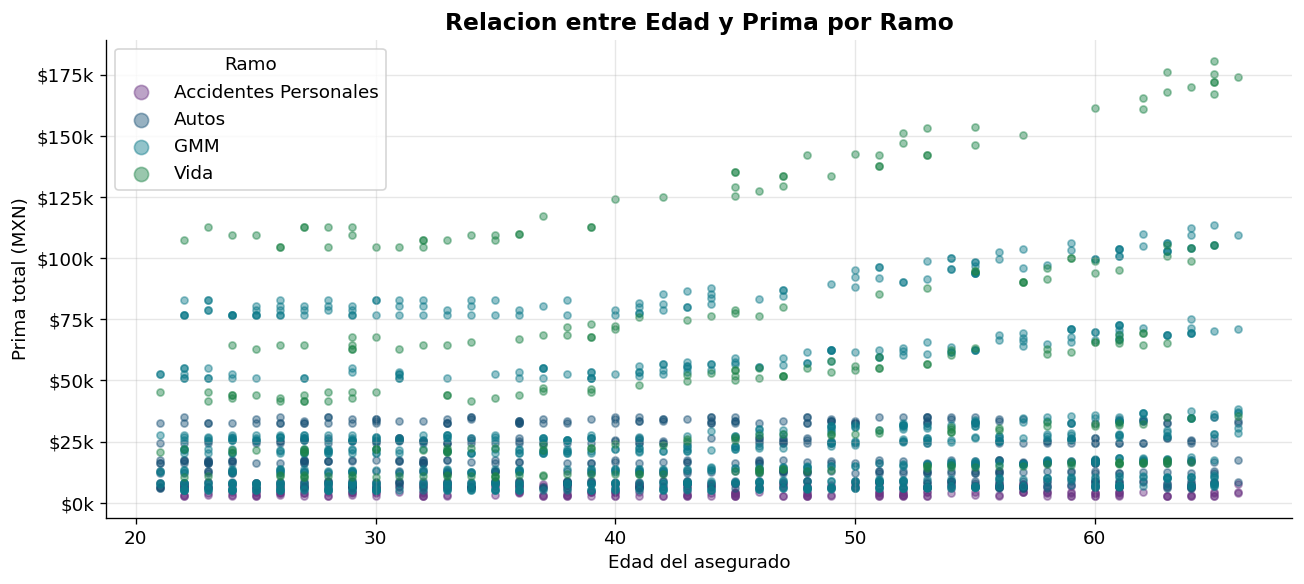

In [20]:
# ── Grafica 4: ¿Hay relacion entre la edad y la prima? ───────────────────────
# Pregunta de negocio: ¿las personas mayores pagan mas? ¿es distinto por ramo?
# Tipo: scatter con color por grupo

muestra = df.sample(min(2000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(11, 5))

for ramo, grupo in muestra.groupby('ramo'):
    ax.scatter(grupo['edad'], grupo['prima_total'],
               label=ramo,
               color=COLORES.get(ramo, '#888888'),
               alpha=0.45, s=18)

ax.set_title('Relacion entre Edad y Prima por Ramo')
ax.set_xlabel('Edad del asegurado')
ax.set_ylabel('Prima total (MXN)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
ax.legend(title='Ramo', markerscale=2)

plt.tight_layout()
plt.show()

# Interpretacion que guias en clase:
# GMM: ¿hay una tendencia positiva con la edad? (mayor edad = mayor riesgo = mayor prima)
# Autos: ¿la edad importa menos que en GMM?
# Vida: ¿los valores son mas altos y dispersos?

---
## Ejercicio de Cierre (10 min)

Construye una grafica que responda esta pregunta:

> **¿Cual es la prima promedio por nivel de riesgo (BAJO, MEDIO, ALTO)?**
> **¿Y es diferente entre ramos?**

Pistas:
- Calcula la prima promedio con `groupby(['nivel_riesgo', 'ramo'])['prima_total'].mean()`
- Usa barras — una barra por nivel de riesgo
- Asegúrate de que el orden sea BAJO → MEDIO → ALTO en el eje X
- Agrega titulo, etiquetas de ejes y colores por nivel de riesgo

C:\Users\gusta\AppData\Local\Temp\ipykernel_9348\176920371.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ramo_riesgo = df.groupby(["nivel_riesgo", "ramo"])["prima_total"].mean().reset_index() # Construimos el dataframe con la prima promedio


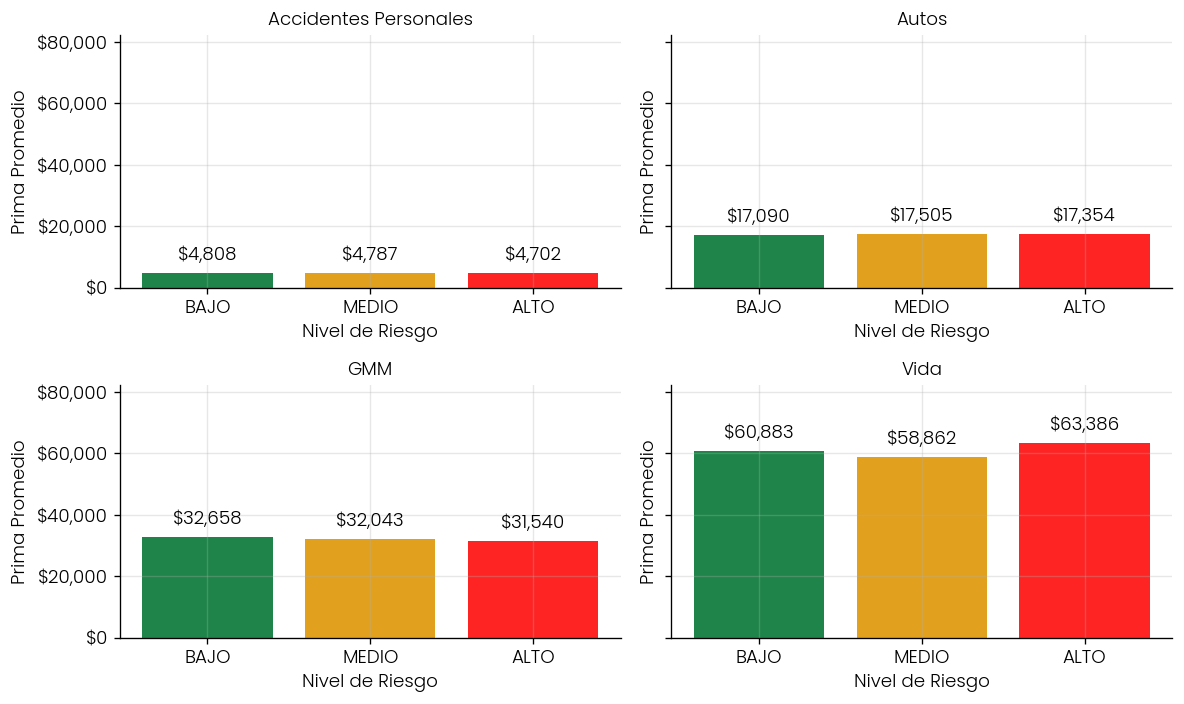

In [66]:
# Tu código aqui
from matplotlib import font_manager as fm
import matplotlib.ticker as mtick

# Formato
poppins_light = fm.FontProperties(fname="Poppins-Light.ttf") # Fuente a elegir
fmt = '${x:,.0f}' # Formato para el eje y
tick_formatter = mtick.StrMethodFormatter(fmt) # Seleccionamos el formato para el eje y
COLORES = {'ALTO':"#FF2424FF",'MEDIO':"#E1A11F",'BAJO':'#1E8449'} # Colores por nivel de riesgo
fig.suptitle("Análisis de Primas Promedio por Ramo y Riesgo", fontproperties=poppins_light, fontsize=16, fontweight='bold') # Titulo general

# Datos
df_ramo_riesgo = df.groupby(["nivel_riesgo", "ramo"])["prima_total"].mean().reset_index() # Construimos el dataframe con la prima promedio
df_ramo_riesgo.reindex(['BAJO','MEDIO','ALTO']) # Aseguramos que el orden se mantenga
ramos = df_ramo_riesgo["ramo"].unique() # Obtenemos los ramos

# Graficas
fig, axes = plt.subplots(2, 2, figsize=(10,6), sharey=True) # Construimos la figura y las graficas en blanco

for ax, ramo in zip(axes.flatten(), ramos): # Construimos todas las gráficas
    ram = df_ramo_riesgo[df_ramo_riesgo["ramo"] == ramo]
    colores_barras = [COLORES.get(r, '#888888') for r in ram["nivel_riesgo"]]
    
    bar = ax.bar(ram["nivel_riesgo"], ram["prima_total"], color=colores_barras)
    
    ax.bar_label(bar, fmt='${:,.0f}', padding=5, fontproperties=poppins_light, fontweight='bold')
    ax.set_title(ramo, fontproperties=poppins_light)
    ax.set_xlabel("Nivel de Riesgo", fontproperties=poppins_light)
    ax.set_ylabel("Prima Promedio", fontproperties=poppins_light)
    ax.set_ylim(0, ram["prima_total"].max() * 1.3)
    ax.yaxis.set_major_formatter(tick_formatter)

    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontproperties(poppins_light)

plt.tight_layout()
plt.show()

In [ ]:
# ── Solucion (descomenta) ────────────────────────────────────────────────────

# prom = df.groupby('nivel_riesgo', observed=True)['prima_total'].mean()
# # Asegurar orden BAJO → MEDIO → ALTO
# prom = prom.reindex(['BAJO','MEDIO','ALTO'])

# fig, ax = plt.subplots(figsize=(8, 4))
# colores_nivel = [COLORES['BAJO'], COLORES['MEDIO'], COLORES['ALTO']]
# barras = ax.bar(prom.index, prom.values, color=colores_nivel, edgecolor='white', width=0.5)
# ax.bar_label(barras, fmt='$%.0f', padding=5, fontweight='bold')
# ax.set_title('Prima Promedio por Nivel de Riesgo')
# ax.set_ylabel('Prima promedio (MXN)')
# ax.set_ylim(0, prom.max() * 1.2)
# plt.tight_layout()
# plt.show()

---
## Resumen de lo que Aprendimos

| Concepto | Descripcion |
|---------|-------------|
| **Jerarquia** | Figure > Axes > elementos — la base de todo |
| **rcParams** | Configuracion global que heredan todas las graficas |
| **fig, ax = plt.subplots()** | El patron correcto — orientado a objetos |
| **Construccion incremental** | Minimo funcional → agregar elementos con proposito |
| **Tipos de grafica** | Barras comparar · Linea tiempo · Histograma distribucion · Scatter relacion |
| **Subplots** | `plt.subplots(filas, cols)` · sharey para comparar escalas |
| **tight_layout()** | Siempre al final para evitar que los textos se corten |

**Proxima sesion — Viernes 8 de mayo — otro profesor:**
Seaborn formal: histplot, boxplot, violinplot, heatmap, pairplot, barplot, lineplot.
Usaran `datos/tabla_maestra_s9.parquet` — ya lo conocen.

---
*Diplomado ML en Seguros · Facultad de Ciencias, UNAM · 2026*